In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from netket.hilbert import Spin
from netket.operator import Ising
from netket.graph import Hypercube
from scipy.sparse.linalg import eigsh
import os
import time

from rbmopt import RBM


∣NK⟩ Tip: With many Markov Chains (e.g GPUs), n_discard_per_chain>5 is often inefficient.

In [2]:
J_field       = 1.0
n_hidden      = 20
batch_size    = 100
learning_rate = 0.01
k_cd          = 5
dataset_size  = 5000

# Para N > N_EXACT_MAX se usa kl_mode='samples' (2^N configs)
N_EXACT_MAX = 14

N_values = [8, 10, 12, 14]

# Convenio: g = h / J
G_values = np.concatenate([
    np.linspace(0.10, 0.85, 5),
    np.linspace(0.9, 1.75, 20),
    np.linspace(1.75, 2.5, 5),
])


In [3]:
def n_epochs_warmstart(g):
    dist = abs(g - 1.0)
    if dist < 0.15:
        return 1500
    elif dist < 0.40:
        return 800
    else:
        return 400

def n_epochs_cold(g):
    dist = abs(g - 1.0)
    if dist < 0.15:
        return 4000
    elif dist < 0.40:
        return 2500
    else:
        return 1500


In [4]:
def get_ground_state(hi, graph, g, all_states):
    # Convenio: g = h / J  ->  h = g * J
    h = g * J_field
    H = Ising(hilbert=hi, graph=graph, h=h, J=J_field)
    _, eigvecs = eigsh(H.to_sparse(), k=1, which='SA')
    psi0       = eigvecs[:, 0]
    psi_prob   = np.abs(psi0) ** 2
    psi_prob  /= psi_prob.sum()

    dist   = abs(g - 1.0)
    n_samp = dataset_size * 2 if dist < 0.20 else dataset_size
    idx    = np.random.choice(len(all_states), size=n_samp, p=psi_prob)
    dataset_bin = ((all_states[idx] + 1) / 2).astype(float)
    return psi_prob, dataset_bin


def train_point(N, g, psi_prob, dataset_bin, all_states,
                warm_W=None, warm_b=None, warm_c=None):
    rbm = RBM(n_visible=N, n_hidden=n_hidden)

    if warm_W is not None:
        rbm.W = warm_W.copy()
        rbm.b = warm_b.copy()
        rbm.c = warm_c.copy()
        n_ep  = n_epochs_warmstart(g)
    else:
        n_ep  = n_epochs_cold(g)

    use_exact = (N <= N_EXACT_MAX)

    history = rbm.train(
        dataset       = dataset_bin,
        n_epochs      = n_ep,
        batch_size    = min(batch_size, len(dataset_bin)),
        learning_rate = learning_rate,
        k             = k_cd,
        log_every     = n_ep - 1,   # garantiza al menos un registro al final
        kl_mode       = 'exact' if use_exact else 'samples',
        psi_prob      = psi_prob if use_exact else None,
        hi_states     = all_states if use_exact else None,
    )
    kl = history[-1][1]
    return kl, rbm.W, rbm.b, rbm.c


In [5]:
def run_for_N(N):
    print(f"Iniciando N={N}  ({len(G_values)} puntos x 2 pasadas)")

    graph      = Hypercube(length=N, n_dim=1, pbc=True)
    hi         = Spin(s=1/2, N=graph.n_nodes)
    all_states = hi.all_states()

    ground_states = {}
    for g in G_values:
        ground_states[g] = get_ground_state(hi, graph, g, all_states)

    n_g    = len(G_values)
    kl_fwd = np.full(n_g, np.nan)
    kl_bwd = np.full(n_g, np.nan)

    print(f"  [N={N}] Pasada 1: g creciente ->")
    W, b, c = None, None, None
    for i, g in enumerate(G_values):
        psi_prob, dataset_bin = ground_states[g]
        t0 = time.time()
        kl, W, b, c = train_point(N, g, psi_prob, dataset_bin, all_states,
                                   warm_W=W, warm_b=b, warm_c=c)
        kl_fwd[i] = kl
        print(f"    g={g:.3f} | KL={kl:.5f} | {time.time()-t0:.1f}s")

    print(f"  [N={N}] Pasada 2: g decreciente <-")
    W, b, c = None, None, None
    for i, g in enumerate(reversed(G_values)):
        idx_orig = n_g - 1 - i
        psi_prob, dataset_bin = ground_states[g]
        t0 = time.time()
        kl, W, b, c = train_point(N, g, psi_prob, dataset_bin, all_states,
                                   warm_W=W, warm_b=b, warm_c=c)
        kl_bwd[idx_orig] = kl
        print(f"    g={g:.3f} | KL={kl:.5f} | {time.time()-t0:.1f}s")

    kl_finals = np.minimum(kl_fwd, kl_bwd)

    np.savetxt(
        f"kl_fss_N{N}.txt",
        np.column_stack([G_values, kl_fwd, kl_bwd, kl_finals]),
        header=f"N={N}  n_hidden={n_hidden}\ng  KL_fwd  KL_bwd  KL_min",
        fmt=["%.4f", "%.8f", "%.8f", "%.8f"]
    )
    print(f"[N={N}] Completado. Guardado en kl_fss_N{N}.txt")
    return kl_finals


In [6]:
t_total = time.time()
results = {}

for N in N_values:
    results[N] = run_for_N(N)

print(f"\nTiempo total: {(time.time()-t_total)/60:.1f} min")


Iniciando N=8  (30 puntos x 2 pasadas)
  [N=8] Pasada 1: g creciente ->
    g=0.100 | KL=0.36856 | 22.3s
    g=0.287 | KL=0.10002 | 4.6s
    g=0.475 | KL=0.01214 | 5.3s
    g=0.662 | KL=0.01925 | 7.8s
    g=0.850 | KL=0.06680 | 6.8s
    g=0.900 | KL=0.08437 | 10.7s
    g=0.945 | KL=0.10314 | 8.9s
    g=0.989 | KL=0.12367 | 8.8s
    g=1.034 | KL=0.14137 | 8.9s
    g=1.079 | KL=0.15578 | 8.9s
    g=1.124 | KL=0.16843 | 8.6s
    g=1.168 | KL=0.17848 | 5.0s
    g=1.213 | KL=0.18565 | 4.4s
    g=1.258 | KL=0.19005 | 4.7s
    g=1.303 | KL=0.19237 | 4.4s
    g=1.347 | KL=0.19283 | 4.6s
    g=1.392 | KL=0.19116 | 4.3s
    g=1.437 | KL=0.18725 | 2.1s
    g=1.482 | KL=0.18452 | 2.2s
    g=1.526 | KL=0.18231 | 2.4s
    g=1.571 | KL=0.17530 | 2.2s
    g=1.616 | KL=0.16925 | 2.4s
    g=1.661 | KL=0.16449 | 2.4s
    g=1.705 | KL=0.15720 | 2.4s
    g=1.750 | KL=0.15276 | 2.4s
    g=1.750 | KL=0.15207 | 2.3s
    g=1.938 | KL=0.12966 | 2.2s
    g=2.125 | KL=0.11115 | 2.4s
    g=2.312 | KL=0.09445 | 2.3

In [7]:
# Tabla resumen: DKL final (kl_min) para cada g y cada N, todo junto en un .txt
summary_path = "kl_fss_summary.txt"

header_cols = "g".rjust(10) + "".join(f"N={N}".rjust(16) for N in N_values)
lines = [header_cols]

for i, g in enumerate(G_values):
    row = f"{g:10.4f}"
    for N in N_values:
        row += f"{results[N][i]:16.8e}"
    lines.append(row)

with open(summary_path, "w") as f:
    f.write(f"# DKL final (minimo entre pasada forward/backward) - TFIM\n")
    f.write(f"# Convenio: g = h / J ,  J = {J_field}\n")
    f.write("\n".join(lines) + "\n")

print(f"Tabla resumen guardada en {summary_path}")


Tabla resumen guardada en kl_fss_summary.txt


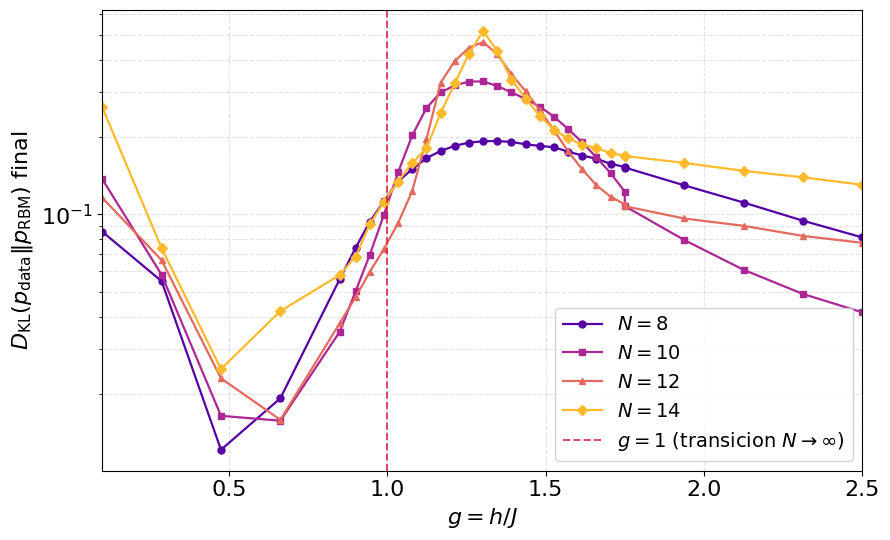

Grafica guardada en kl_fss_TFIM.png


In [ ]:
fig, ax = plt.subplots(figsize=(9, 5.5))

colors  = cm.plasma(np.linspace(0.15, 0.85, len(N_values)))
markers = ['o', 's', '^', 'D']

for N, color, marker in zip(N_values, colors, markers):
    label = f"$N={N}$" + (" (samples)" if N > N_EXACT_MAX else "")
    ax.plot(G_values, results[N],
            color=color, marker=marker,
            markersize=5, linewidth=1.6,
            label=label)

ax.axvline(x=1.0, color='crimson', linestyle='--',
           linewidth=1.4, alpha=0.8,
           label="$g=1$ (transicion $N\\to\\infty$)")

ax.set_xlabel("$g = h/J$", fontsize=16)
ax.set_ylabel(
    r"$D_{\mathrm{KL}}(p_{\mathrm{data}} \| p_{\mathrm{RBM}})$ final",
    fontsize=16)
ax.tick_params(axis='both', which='major', labelsize=16)
ax.legend(fontsize=14, framealpha=0.85)
ax.set_yscale("linear")
ax.grid(True, which="both", linestyle="--", alpha=0.35)
ax.set_xlim(G_values[0], G_values[-1])

plt.tight_layout()
plt.savefig("kl_fss_TFIM.png", dpi=150, bbox_inches="tight")
plt.show()
print("Grafica guardada en kl_fss_TFIM.png")


Cargado: kl_fss_N8.txt
Cargado: kl_fss_N10.txt
Cargado: kl_fss_N12.txt
Cargado: kl_fss_N14.txt


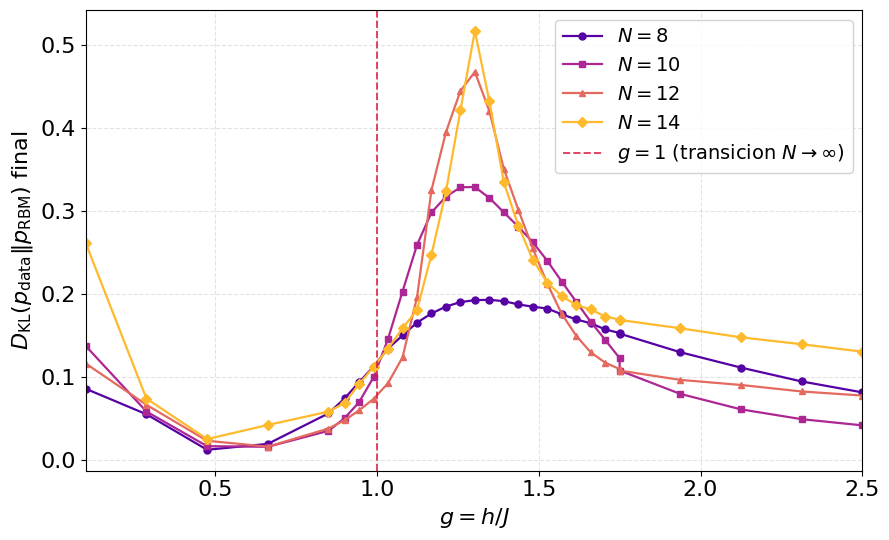

In [9]:
# Abrimos los archivos guardados para generar una grafica comparativa para cada N,
# mostrando KL vs g. Se pueden comparar las curvas de KL para diferentes N y observar
# el comportamiento cerca de g=1.

N_values = [8, 10, 12, 14]
kl_data = {}
for N in N_values:
    filename = f"kl_fss_N{N}.txt"
    if os.path.isfile(filename):
        data = np.loadtxt(filename, skiprows=2)
        kl_data[N] = data
        print(f"Cargado: {filename}")
    else:
        print(f"Archivo no encontrado: {filename}")

# kl_data[N] contiene columnas: g, KL_fwd, KL_bwd, KL_min para cada N.
# Graficamos KL_min vs g para cada N en una sola figura.

fig, ax = plt.subplots(figsize=(9, 5.5))
colors  = cm.plasma(np.linspace(0.15, 0.85, len(N_values)))
markers = ['o', 's', '^', 'D']
for N, color, marker in zip(N_values, colors, markers):
    if N in kl_data:
        g = kl_data[N][:, 0]
        kl_min = kl_data[N][:, 3]
        label = f"$N={N}$" + (" (samples)" if N > N_EXACT_MAX else "")
        ax.plot(g, kl_min,
                color=color, marker=marker,
                markersize=5, linewidth=1.6,
                label=label)

ax.axvline(x=1.0, color='crimson', linestyle='--',
           linewidth=1.4, alpha=0.8,
           label="$g=1$ (transicion $N\\to\\infty$)")
ax.set_xlabel("$g = h/J$", fontsize=16)
ax.set_ylabel(
    r"$D_{\mathrm{KL}}(p_{\mathrm{data}} \| p_{\mathrm{RBM}})$ final",
    fontsize=16)
ax.tick_params(axis='both', which='major', labelsize=16)
ax.legend(fontsize=14, framealpha=0.85)
ax.set_yscale("linear")
ax.grid(True, which="both", linestyle="--", alpha=0.35)
ax.set_xlim(g[0], g[-1])
plt.tight_layout()
plt.savefig("kl_fss_TFIM_reload.png", dpi=150, bbox_inches="tight")
plt.show()
